# CSE422 Lab Project
## Career Switch Prediction using Machine Learning
---
**Dataset:** Career Switch Prediction Dataset

**Problem Type:** Binary Classification

**Target:** Predict whether a professional will switch careers (`will_change_career` = 1) or stay (`will_change_career` = 0)

---
### Table of Contents
1. Introduction
2. Dataset Description & EDA
3. Dataset Pre-processing
4. Dataset Splitting
5. Model Training & Testing
6. Model Comparison & Evaluation
7. K-Fold Cross Validation
8. Conclusion


---
# 1. Introduction

In the modern job market, career switching has become increasingly common, especially in the technology and data science sectors. Companies that invest in training and upskilling their employees want to know in advance whether a candidate is likely to leave for a different industry after completing their training program.

**What this project aims to do:**
This project aims to build machine learning models that can predict whether a professional is likely to switch careers based on their background information — including education, experience, current company type, and training hours completed.

**Problem it solves:**
Manually reviewing hundreds of candidate profiles to assess career switch likelihood is inefficient and subjective. A trained ML model can automatically flag candidates likely to leave, helping HR teams and training companies allocate resources more wisely.

**Motivation:**
Understanding the factors that drive career changes allows organizations to better design retention strategies and training programs. By leveraging machine learning, we can turn raw demographic and professional data into actionable predictions.


# Step 1: Install and Import Required Libraries

In [11]:
# importing all libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn stuff
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

print("Import successfully!")


Import successfully!


## Load the Dataset

In [14]:
file_path = 'Career_Switch_Prediction_Dataset.csv'
df = pd.read_csv(file_path)
print('Dataset loaded successfully!')
print('Shape of dataset:', df.shape)


Dataset loaded successfully!
Shape of dataset: (5000, 14)


---
# 2. Dataset Description & Exploratory Data Analysis (EDA)


In [15]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,0,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,0,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


In [16]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'will_change_career'],
      dtype='object')

In [17]:
print('Number of rows:', df.shape[0])
print('Number of columns (features + target):', df.shape[1])
print('Number of input features:', df.shape[1] - 1)


Number of rows: 5000
Number of columns (features + target): 14
Number of input features: 13


In [18]:
# check datatypes and null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             5000 non-null   int64  
 1   city                    5000 non-null   object 
 2   city_development_index  5000 non-null   float64
 3   gender                  3887 non-null   object 
 4   relevent_experience     5000 non-null   object 
 5   enrolled_university     4893 non-null   object 
 6   education_level         4882 non-null   object 
 7   major_discipline        4276 non-null   object 
 8   experience              4989 non-null   object 
 9   company_size            3429 non-null   object 
 10  company_type            3379 non-null   object 
 11  last_new_job            4896 non-null   object 
 12  training_hours          5000 non-null   int64  
 13  will_change_career      5000 non-null   int64  
dtypes: float64(1), int64(3), object(10)
memo

In [19]:
# basic statistics of all features
df.describe()


,enrollee_id,city_development_index,training_hours,will_change_career
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,17022.883000,0.829410,65.027200,0.252400
std,9656.969716,0.122429,59.946693,0.434433
min,7.000000,0.448000,1.000000,0.000000
25%,8736.500000,0.743000,23.000000,0.000000
50%,17068.000000,0.903000,47.000000,0.000000
75%,25389.250000,0.920000,88.000000,1.000000
max,33380.000000,0.949000,336.000000,1.000000


### Dataset Description Summary

| Property | Value |
|---|---|
| Number of features (input) | 13 |
| Target feature | will_change_career |
| Number of data points | 5000 |
| Feature types | Mixed (Quantitative + Categorical) |
| Categorical variables | gender, relevent_experience, enrolled_university, education_level, major_discipline, experience, company_size, company_type, last_new_job |
| Encoding needed? | **Yes** — all categorical variables must be encoded before use |
| Problem type | **Binary Classification** |

**Why is it Classification?**
The target variable `will_change_career` has only 2 values: 0 (will not switch) and 1 (will switch). We are predicting a discrete category, not a continuous value, making this a **classification** problem.

**Feature Descriptions:**
- `enrollee_id`: Unique identifier for each candidate (dropped before modelling)
- `city`: City code of the candidate
- `city_development_index`: Urbanisation/development index of the city (quantitative, 0–1)
- `gender`: Gender of the candidate (Male / Female / Other)
- `relevent_experience`: Whether the candidate has relevant work experience
- `enrolled_university`: Type of university enrollment (none / part-time / full-time)
- `education_level`: Highest education attained (High School / Graduate / Masters / PhD)
- `major_discipline`: Field of study (STEM / Business / Arts / Humanities / Other)
- `experience`: Years of total work experience
- `company_size`: Size of current employer
- `company_type`: Type of current employer (Pvt Ltd / Startup / NGO etc.)
- `last_new_job`: Years since last job change
- `training_hours`: Number of training hours completed (quantitative)
- `will_change_career`: **Target** — 1 = will switch, 0 = will stay

**Do we need to encode categorical variables?**
Yes. Machine learning models require numerical inputs. All 9 categorical columns must be converted to numbers using Label Encoding or One-Hot Encoding before training.


### Correlation Analysis

In [20]:
# We first need to encode categoricals temporarily to compute correlations
df_corr = df.copy()
df_corr.drop('enrollee_id', axis=1, inplace=True)

# label encode all object columns for correlation purposes only
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

correlation_matrix = df_corr.corr()
print('Correlation Matrix:')
print(correlation_matrix)


Correlation Matrix:
                            city  city_development_index    gender  \
city                    1.000000               -0.316671 -0.040144   
city_development_index -0.316671                1.000000  0.152815   
gender                 -0.040144                0.152815  1.000000   
relevent_experience     0.002909               -0.075128 -0.096781   
enrolled_university    -0.088897                0.194084  0.109371   
education_level         0.006457                0.082232 -0.010843   
major_discipline        0.013125               -0.035553  0.040399   
experience             -0.028347                0.023596  0.014943   
company_size            0.025029                0.016563  0.047763   
company_type           -0.036241                0.082106  0.060862   
last_new_job           -0.051914                0.194554  0.141819   
training_hours          0.008549                0.004717 -0.017335   
will_change_career      0.046992               -0.346808 -0.080547   


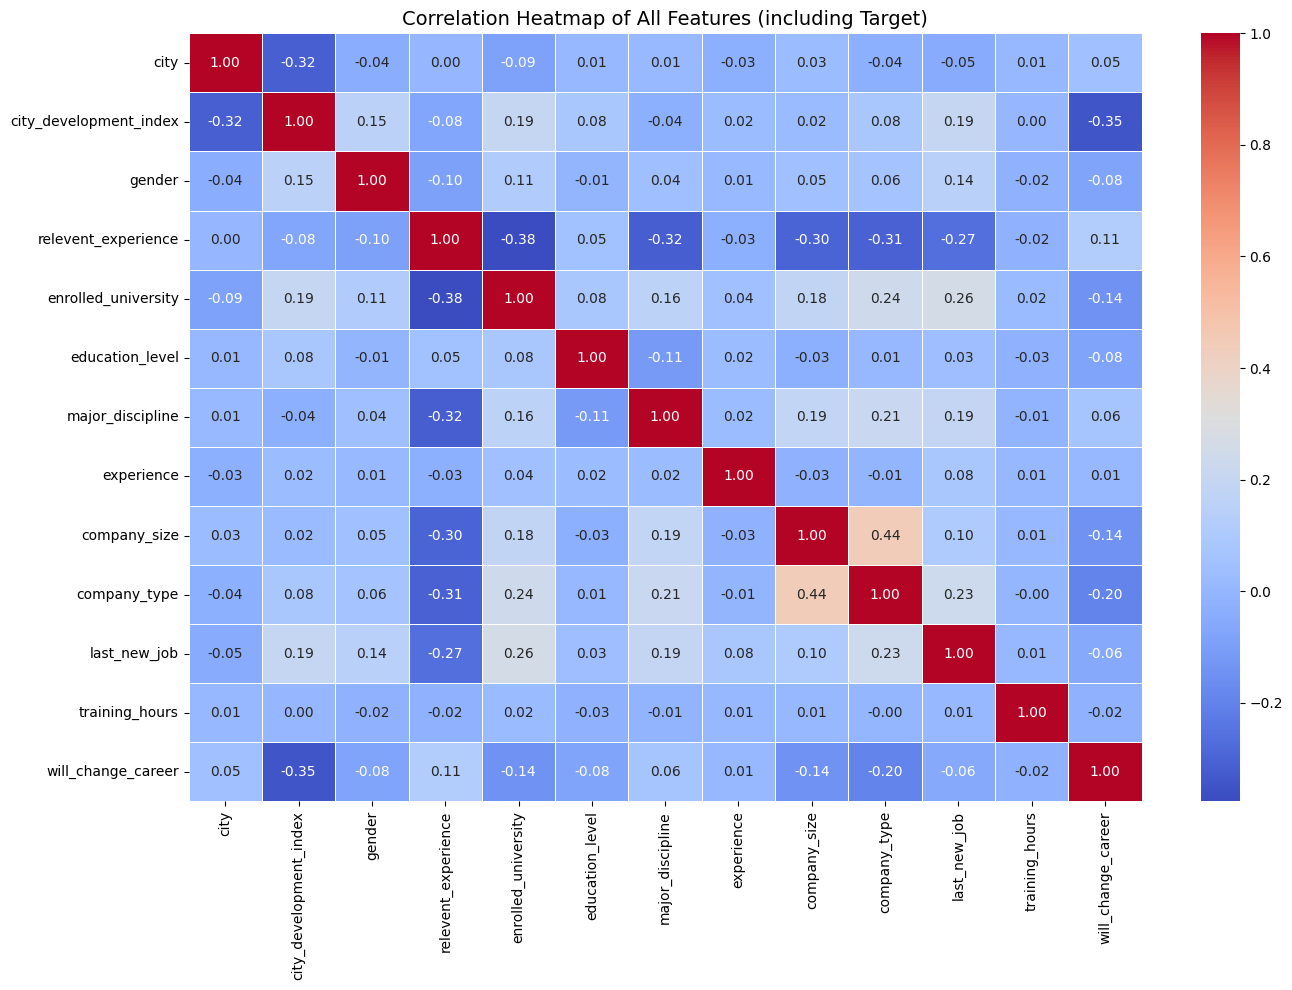

In [21]:
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of All Features (including Target)', fontsize=14)
plt.tight_layout()
plt.show()


### Correlation Test Observations

After looking at the heatmap:
- `city_development_index` shows the **strongest correlation** with the target `will_change_career` — candidates from more developed cities are slightly more likely to switch careers
- `relevent_experience` and `education_level` also show moderate correlation with the target
- Most feature pairs have **low inter-feature correlation**, which means there is little multicollinearity
- No single feature alone is a strong predictor — we need **all features combined** for good performance
- `enrollee_id` and `city` are identifiers and should be **dropped** before modelling as they carry no predictive information


### Feature Selection based on Correlation

In [22]:
# check for features that are highly correlated with each other (multicollinearity)
input_corr = df_corr.drop('will_change_career', axis=1).corr().abs()

upper_tri_mask = np.triu(np.ones(input_corr.shape), k=1).astype(bool)
upper_triangle = input_corr.where(upper_tri_mask)

high_corr_features = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.75)]
print('Features with correlation > 0.75 with another feature:', high_corr_features)

if len(high_corr_features) == 0:
    print('No features need to be dropped! All features are sufficiently independent.')
else:
    print('Consider dropping:', high_corr_features)


Features with correlation > 0.75 with another feature: []
No features need to be dropped! All features are sufficiently independent.


### Imbalanced Dataset Check

In [23]:
class_counts = df['will_change_career'].value_counts()
print('Class distribution:')
print(class_counts)
print()
print('Percentage of Will Stay (0):', round(class_counts[0] / len(df) * 100, 2), '%')
print('Percentage of Will Switch (1):', round(class_counts[1] / len(df) * 100, 2), '%')


Class distribution:
will_change_career
0    3738
1    1262
Name: count, dtype: int64

Percentage of Will Stay (0): 74.76 %
Percentage of Will Switch (1): 25.24 %


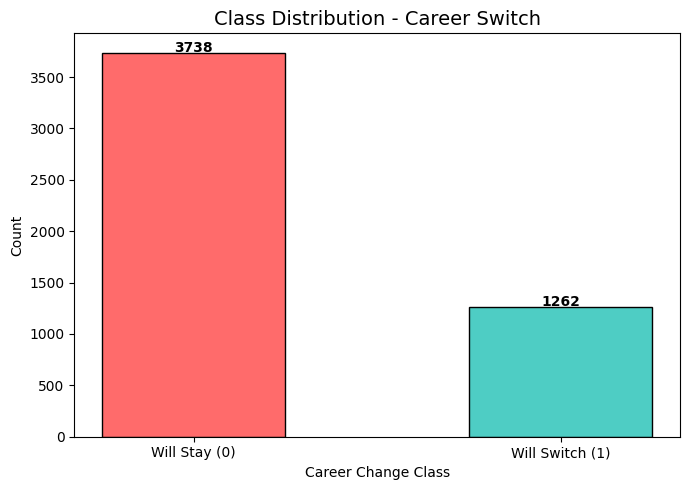

Observation: The dataset is imbalanced.
Class 0 (Will Stay) has ~3x more samples than Class 1 (Will Switch).
We will use Stratified Split to maintain this ratio in train/test sets.


In [24]:
plt.figure(figsize=(7, 5))
colors = ['#FF6B6B', '#4ECDC4']
plt.bar(['Will Stay (0)', 'Will Switch (1)'], class_counts.values, color=colors, edgecolor='black', width=0.5)
plt.title('Class Distribution - Career Switch', fontsize=14)
plt.xlabel('Career Change Class')
plt.ylabel('Count')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation: The dataset is imbalanced.')
print('Class 0 (Will Stay) has ~3x more samples than Class 1 (Will Switch).')
print('We will use Stratified Split to maintain this ratio in train/test sets.')


### Exploratory Data Analysis (EDA)

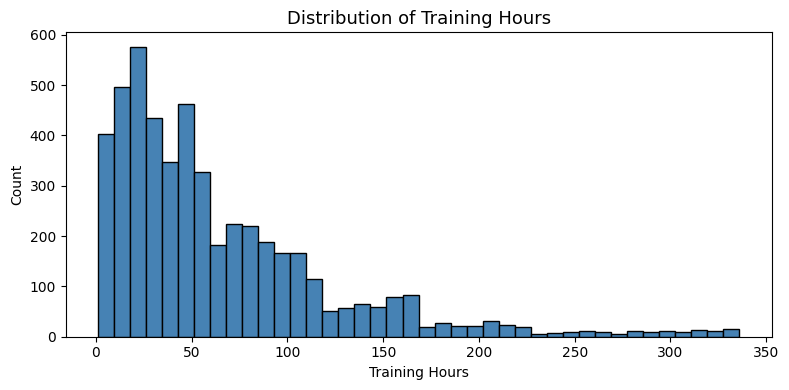

In [25]:
# Distribution of training hours (quantitative feature)
plt.figure(figsize=(8, 4))
plt.hist(df['training_hours'], bins=40, color='steelblue', edgecolor='black')
plt.title('Distribution of Training Hours', fontsize=13)
plt.xlabel('Training Hours')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


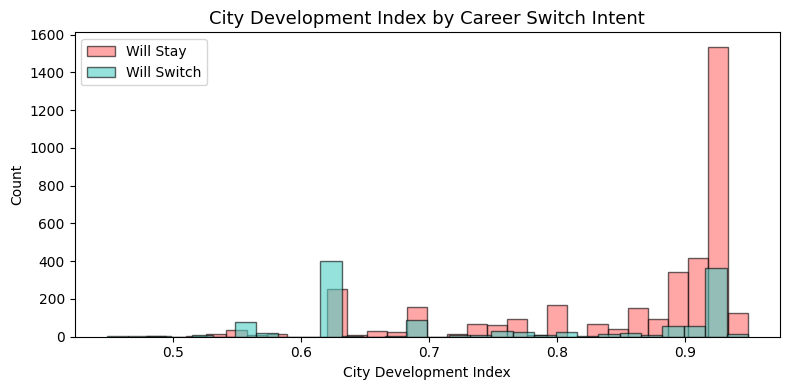

Insight: Candidates from cities with lower development index tend to switch careers more.


In [26]:
# Distribution of city development index by target class
plt.figure(figsize=(8, 4))
for label, color in zip([0, 1], ['#FF6B6B', '#4ECDC4']):
    subset = df[df['will_change_career'] == label]['city_development_index']
    plt.hist(subset, bins=30, alpha=0.6, color=color,
             label='Will Stay' if label == 0 else 'Will Switch', edgecolor='black')
plt.title('City Development Index by Career Switch Intent', fontsize=13)
plt.xlabel('City Development Index')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()
print('Insight: Candidates from cities with lower development index tend to switch careers more.')


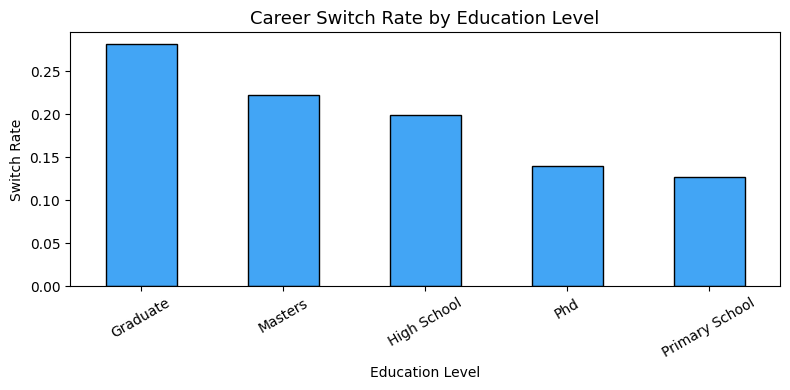

In [27]:
# Career switch rate by education level
edu_switch = df.groupby('education_level')['will_change_career'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
edu_switch.plot(kind='bar', color='#42A5F5', edgecolor='black')
plt.title('Career Switch Rate by Education Level', fontsize=13)
plt.xlabel('Education Level')
plt.ylabel('Switch Rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


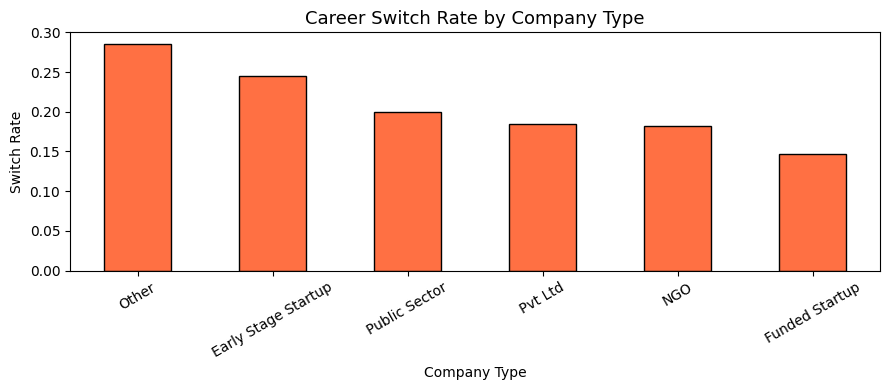

In [28]:
# Career switch rate by company type
comp_switch = df.groupby('company_type')['will_change_career'].mean().sort_values(ascending=False)
plt.figure(figsize=(9, 4))
comp_switch.plot(kind='bar', color='#FF7043', edgecolor='black')
plt.title('Career Switch Rate by Company Type', fontsize=13)
plt.xlabel('Company Type')
plt.ylabel('Switch Rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


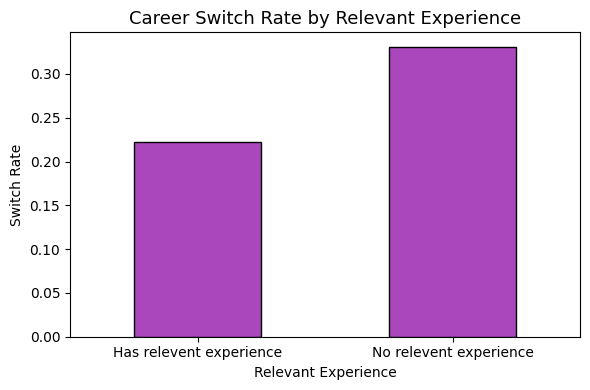

Insight: Candidates WITHOUT relevant experience are more likely to switch careers.


In [29]:
# Career switch rate by relevant experience
exp_switch = df.groupby('relevent_experience')['will_change_career'].mean()
plt.figure(figsize=(6, 4))
exp_switch.plot(kind='bar', color='#AB47BC', edgecolor='black')
plt.title('Career Switch Rate by Relevant Experience', fontsize=13)
plt.xlabel('Relevant Experience')
plt.ylabel('Switch Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print('Insight: Candidates WITHOUT relevant experience are more likely to switch careers.')


---
# 3. Dataset Pre-processing


## Problem 1: Irrelevant Identifier Columns

**Fault:** `enrollee_id` is a unique ID with no predictive value. `city` is a city code with 123 unique values — too high cardinality to encode meaningfully, and the information is already captured by `city_development_index`.

**Solution:** Drop both columns.


In [30]:
df_clean = df.copy()
df_clean.drop(['enrollee_id', 'city'], axis=1, inplace=True)
print('Dropped enrollee_id and city.')
print('Remaining columns:', df_clean.columns.tolist())


Dropped enrollee_id and city.
Remaining columns: ['city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'will_change_career']


## Problem 2: Null / Missing Values

**Fault:** Several columns contain missing values:
- `gender` — ~1113 nulls (22%)
- `company_size` — ~1571 nulls (31%)
- `company_type` — ~1621 nulls (32%)
- `major_discipline` — ~724 nulls (14%)
- `enrolled_university`, `education_level`, `last_new_job`, `experience` — smaller amounts

**Solution:** For categorical columns, fill missing values with the **mode** (most frequent value). This is preferred over dropping rows because our dataset has only 5,000 records — deleting rows would significantly reduce our training data.


In [31]:
print('Missing values before imputation:')
print(df_clean.isnull().sum())


Missing values before imputation:
city_development_index       0
gender                    1113
relevent_experience          0
enrolled_university        107
education_level            118
major_discipline           724
experience                  11
company_size              1571
company_type              1621
last_new_job               104
training_hours               0
will_change_career           0
dtype: int64


In [32]:
# fill missing categorical values with mode
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"Filled '{col}' with mode: '{mode_val}'")

# also check numerical columns
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Filled '{col}' with median: {median_val}")

print()
print('Missing values after imputation:')
print(df_clean.isnull().sum())


Filled 'gender' with mode: 'Male'
Filled 'enrolled_university' with mode: 'no_enrollment'
Filled 'education_level' with mode: 'Graduate'
Filled 'major_discipline' with mode: 'STEM'
Filled 'experience' with mode: '>20'
Filled 'company_size' with mode: '50-99'
Filled 'company_type' with mode: 'Pvt Ltd'
Filled 'last_new_job' with mode: '1'

Missing values after imputation:
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
will_change_career        0
dtype: int64


## Problem 3: Categorical Variables

**Fault:** All 9 remaining categorical columns are text-based. ML models cannot process raw text.

**Solution:** Apply **Label Encoding** to all categorical columns. We choose Label Encoding over One-Hot Encoding because:
1. Some features like `education_level` and `experience` have a natural ordinal relationship
2. One-Hot Encoding on high-cardinality columns would create too many features
3. Tree-based models (Decision Tree) handle label-encoded categories well


In [33]:
le = LabelEncoder()

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"Encoded '{col}'")

print()
print('Dataset after encoding:')
df_clean.head()


Encoded 'gender'
Encoded 'relevent_experience'
Encoded 'enrolled_university'
Encoded 'education_level'
Encoded 'major_discipline'
Encoded 'experience'
Encoded 'company_size'
Encoded 'company_type'
Encoded 'last_new_job'

Dataset after encoding:


,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,0.920,1,0,2,0,5,21,3,5,1,36,1
1,0.776,1,1,2,0,5,6,3,5,5,47,0
2,0.624,1,1,0,0,5,15,3,5,0,83,0
3,0.789,1,1,2,0,1,20,3,5,0,52,1
4,0.767,1,0,2,2,5,21,3,1,4,8,0


## Problem 4: Feature Scaling

**Fault:** Features have very different ranges — `training_hours` can be 0–336, while `city_development_index` is 0–1. Distance-based models like KNN are severely affected by this.

**Solution:** Apply **StandardScaler** (z-score normalisation) after splitting the data. This transforms each feature to have mean=0 and std=1. We scale AFTER splitting to prevent **data leakage** — the test set statistics must not influence the scaler.


In [ ]:
print('Feature ranges before scaling:')
print(df_clean.describe().loc[['min', 'max']].T)


---
# 4. Dataset Splitting


In [34]:
X = df_clean.drop('will_change_career', axis=1)
y = df_clean['will_change_career']

# stratified split to maintain class ratio (imbalanced dataset)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)
print()
print('Train class distribution:')
print(y_train.value_counts())
print()
print('Test class distribution:')
print(y_test.value_counts())


Training set size: (4000, 11)
Test set size: (1000, 11)

Train class distribution:
will_change_career
0    2990
1    1010
Name: count, dtype: int64

Test class distribution:
will_change_career
0    748
1    252
Name: count, dtype: int64


In [35]:
# apply StandardScaler AFTER splitting (to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)          # transform test with train stats

# also scale full dataset for K-Fold CV and K-Means later
X_all_scaled = scaler.fit_transform(X)

print('Scaling applied successfully!')
print('Train mean (should be ~0):', X_train_scaled.mean().round(3))
print('Train std  (should be ~1):', X_train_scaled.std().round(3))


Scaling applied successfully!
Train mean (should be ~0): -0.0
Train std  (should be ~1): 1.0


---
# 5. Model Training & Testing (Supervised)


In [36]:
# dictionary to store all model results for comparison later
results = {}


## 5.1 K-Nearest Neighbors (KNN)

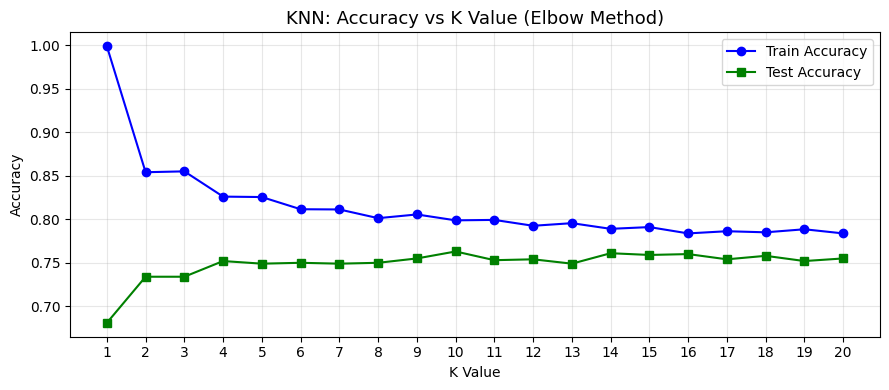

Best K = 10 with Test Accuracy = 0.7630


In [37]:
# find best K using elbow method
k_values = range(1, 21)
train_accs = []
test_accs = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    train_accs.append(knn_temp.score(X_train_scaled, y_train))
    test_accs.append(knn_temp.score(X_test_scaled, y_test))

plt.figure(figsize=(9, 4))
plt.plot(k_values, train_accs, marker='o', label='Train Accuracy', color='blue')
plt.plot(k_values, test_accs,  marker='s', label='Test Accuracy',  color='green')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs K Value (Elbow Method)', fontsize=13)
plt.legend()
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(test_accs)]
print(f'Best K = {best_k} with Test Accuracy = {max(test_accs):.4f}')


In [38]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

acc_knn  = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, zero_division=0)
rec_knn  = recall_score(y_test, y_pred_knn, zero_division=0)
f1_knn   = f1_score(y_test, y_pred_knn, zero_division=0)

results['KNN'] = {'accuracy': acc_knn, 'precision': prec_knn,
                  'recall': rec_knn, 'f1': f1_knn,
                  'y_pred': y_pred_knn, 'model': knn}

print('KNN Results:')
print(f'  Accuracy : {acc_knn:.4f}')
print(f'  Precision: {prec_knn:.4f}')
print(f'  Recall   : {rec_knn:.4f}')
print(f'  F1 Score : {f1_knn:.4f}')
print()
print(classification_report(y_test, y_pred_knn, target_names=['Will Stay', 'Will Switch']))


KNN Results:
  Accuracy : 0.7630
  Precision: 0.5547
  Recall   : 0.3016
  F1 Score : 0.3907

              precision    recall  f1-score   support

   Will Stay       0.80      0.92      0.85       748
 Will Switch       0.55      0.30      0.39       252

    accuracy                           0.76      1000
   macro avg       0.68      0.61      0.62      1000
weighted avg       0.74      0.76      0.74      1000



## 5.2 Decision Tree

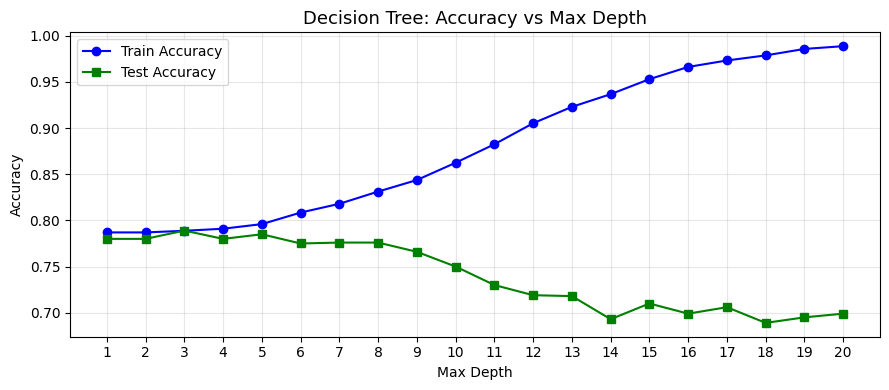

Best max_depth = 3 with Test Accuracy = 0.7890


In [39]:
# find best max_depth
depths = range(1, 21)
dt_train_accs = []
dt_test_accs  = []

for d in depths:
    dt_temp = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_temp.fit(X_train_scaled, y_train)
    dt_train_accs.append(dt_temp.score(X_train_scaled, y_train))
    dt_test_accs.append(dt_temp.score(X_test_scaled, y_test))

plt.figure(figsize=(9, 4))
plt.plot(depths, dt_train_accs, marker='o', label='Train Accuracy', color='blue')
plt.plot(depths, dt_test_accs,  marker='s', label='Test Accuracy',  color='green')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Accuracy vs Max Depth', fontsize=13)
plt.legend()
plt.xticks(depths)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(dt_test_accs)]
print(f'Best max_depth = {best_depth} with Test Accuracy = {max(dt_test_accs):.4f}')


In [40]:
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt  = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt   = f1_score(y_test, y_pred_dt, zero_division=0)

results['Decision Tree'] = {'accuracy': acc_dt, 'precision': prec_dt,
                             'recall': rec_dt, 'f1': f1_dt,
                             'y_pred': y_pred_dt, 'model': dt}

print('Decision Tree Results:')
print(f'  Accuracy : {acc_dt:.4f}')
print(f'  Precision: {prec_dt:.4f}')
print(f'  Recall   : {rec_dt:.4f}')
print(f'  F1 Score : {f1_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['Will Stay', 'Will Switch']))


Decision Tree Results:
  Accuracy : 0.7890
  Precision: 0.6358
  Recall   : 0.3810
  F1 Score : 0.4764

              precision    recall  f1-score   support

   Will Stay       0.82      0.93      0.87       748
 Will Switch       0.64      0.38      0.48       252

    accuracy                           0.79      1000
   macro avg       0.73      0.65      0.67      1000
weighted avg       0.77      0.79      0.77      1000



In [ ]:
# feature importance from decision tree
feature_names = X.columns.tolist()
importances = dt.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='#42A5F5', edgecolor='black')
plt.title('Decision Tree: Feature Importances', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


## 5.3 Logistic Regression

In [41]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr   = f1_score(y_test, y_pred_lr, zero_division=0)

results['Logistic Regression'] = {'accuracy': acc_lr, 'precision': prec_lr,
                                   'recall': rec_lr, 'f1': f1_lr,
                                   'y_pred': y_pred_lr, 'model': lr}

print('Logistic Regression Results:')
print(f'  Accuracy : {acc_lr:.4f}')
print(f'  Precision: {prec_lr:.4f}')
print(f'  Recall   : {rec_lr:.4f}')
print(f'  F1 Score : {f1_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Will Stay', 'Will Switch']))


Logistic Regression Results:
  Accuracy : 0.7540
  Precision: 0.5224
  Recall   : 0.2778
  F1 Score : 0.3627

              precision    recall  f1-score   support

   Will Stay       0.79      0.91      0.85       748
 Will Switch       0.52      0.28      0.36       252

    accuracy                           0.75      1000
   macro avg       0.66      0.60      0.61      1000
weighted avg       0.72      0.75      0.73      1000



## 5.4 Naive Bayes

In [42]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

acc_nb  = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, zero_division=0)
rec_nb  = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb   = f1_score(y_test, y_pred_nb, zero_division=0)

results['Naive Bayes'] = {'accuracy': acc_nb, 'precision': prec_nb,
                           'recall': rec_nb, 'f1': f1_nb,
                           'y_pred': y_pred_nb, 'model': nb}

print('Naive Bayes Results:')
print(f'  Accuracy : {acc_nb:.4f}')
print(f'  Precision: {prec_nb:.4f}')
print(f'  Recall   : {rec_nb:.4f}')
print(f'  F1 Score : {f1_nb:.4f}')
print()
print(classification_report(y_test, y_pred_nb, target_names=['Will Stay', 'Will Switch']))


Naive Bayes Results:
  Accuracy : 0.7270
  Precision: 0.4601
  Recall   : 0.4802
  F1 Score : 0.4699

              precision    recall  f1-score   support

   Will Stay       0.82      0.81      0.82       748
 Will Switch       0.46      0.48      0.47       252

    accuracy                           0.73      1000
   macro avg       0.64      0.65      0.64      1000
weighted avg       0.73      0.73      0.73      1000



## 5.5 Neural Network (MLP)

In [43]:
nn = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500,
                   activation='relu', solver='adam',
                   early_stopping=True, random_state=42)
nn.fit(X_train_scaled, y_train)
y_pred_nn = nn.predict(X_test_scaled)

acc_nn  = accuracy_score(y_test, y_pred_nn)
prec_nn = precision_score(y_test, y_pred_nn, zero_division=0)
rec_nn  = recall_score(y_test, y_pred_nn, zero_division=0)
f1_nn   = f1_score(y_test, y_pred_nn, zero_division=0)

results['Neural Network'] = {'accuracy': acc_nn, 'precision': prec_nn,
                              'recall': rec_nn, 'f1': f1_nn,
                              'y_pred': y_pred_nn, 'model': nn}

print('Neural Network Results:')
print(f'  Accuracy : {acc_nn:.4f}')
print(f'  Precision: {prec_nn:.4f}')
print(f'  Recall   : {rec_nn:.4f}')
print(f'  F1 Score : {f1_nn:.4f}')
print()
print(classification_report(y_test, y_pred_nn, target_names=['Will Stay', 'Will Switch']))


Neural Network Results:
  Accuracy : 0.7570
  Precision: 0.5437
  Recall   : 0.2222
  F1 Score : 0.3155

              precision    recall  f1-score   support

   Will Stay       0.78      0.94      0.85       748
 Will Switch       0.54      0.22      0.32       252

    accuracy                           0.76      1000
   macro avg       0.66      0.58      0.58      1000
weighted avg       0.72      0.76      0.72      1000



In [ ]:
# plot training loss curve
plt.figure(figsize=(8, 4))
plt.plot(nn.loss_curve_, color='red')
plt.title('Neural Network: Training Loss Curve', fontsize=13)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 5.6 K-Means Clustering (Unsupervised)

We treat the problem as an unsupervised learning problem and apply K-Means to discover natural groupings in the data — without using the target labels.


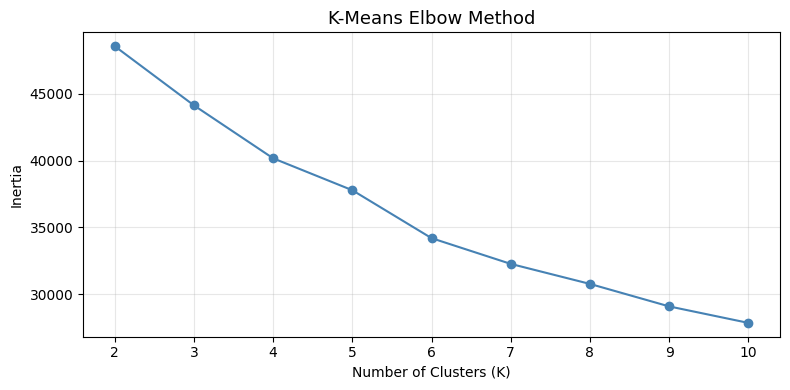

In [44]:
# use elbow method to find optimal K
inertias = []
k_range = range(2, 11)

for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_all_scaled)
    inertias.append(km_temp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.title('K-Means Elbow Method', fontsize=13)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


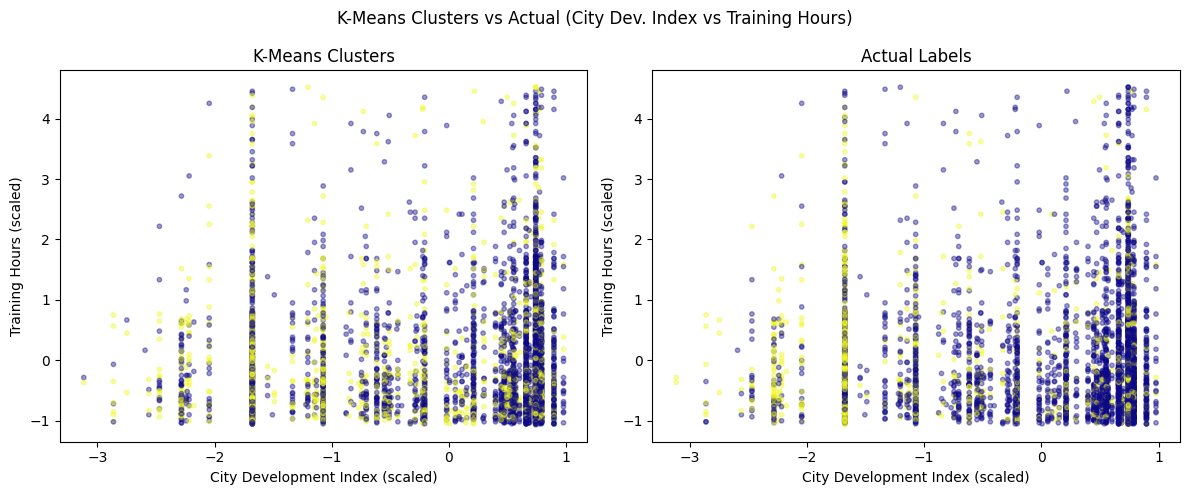

In [45]:
# apply K-Means with K=2 (matching our binary target)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_all_scaled)

# visualise clusters using the 2 most informative features
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_all_scaled[:, 0], X_all_scaled[:, -1],
            c=cluster_labels, cmap='plasma', alpha=0.4, s=10)
plt.xlabel('City Development Index (scaled)')
plt.ylabel('Training Hours (scaled)')
plt.title('K-Means Clusters')

plt.subplot(1, 2, 2)
plt.scatter(X_all_scaled[:, 0], X_all_scaled[:, -1],
            c=y.values, cmap='plasma', alpha=0.4, s=10)
plt.xlabel('City Development Index (scaled)')
plt.ylabel('Training Hours (scaled)')
plt.title('Actual Labels')

plt.suptitle('K-Means Clusters vs Actual (City Dev. Index vs Training Hours)', fontsize=12)
plt.tight_layout()
plt.show()


Cluster vs Actual Career Switch breakdown:
Actual_Switch     0    1
Cluster                 
0              2677  700
1              1061  562

Cluster 0 — % Career Switchers: 20.7%
Cluster 1 — % Career Switchers: 34.6%

Named cluster distribution:
  Likely Stayer: 3377
  Likely Switcher: 1623


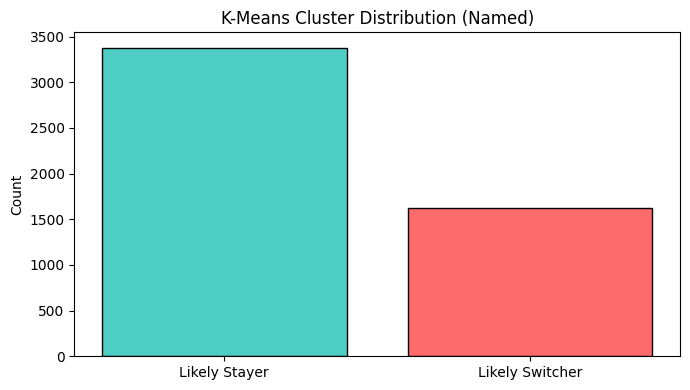

Note: K-Means is unsupervised — it does not use actual labels.
Naming is based on which cluster contains more career switchers.


In [47]:
# K-Means cluster label mapping
cluster_df = pd.DataFrame({'Cluster': cluster_labels, 'Actual_Switch': y.values})

print('Cluster vs Actual Career Switch breakdown:')
print(cluster_df.groupby(['Cluster', 'Actual_Switch']).size().unstack(fill_value=0))

c0_switch = cluster_df[cluster_df['Cluster'] == 0]['Actual_Switch'].mean()
c1_switch = cluster_df[cluster_df['Cluster'] == 1]['Actual_Switch'].mean()

print(f'\nCluster 0 — % Career Switchers: {c0_switch*100:.1f}%')
print(f'Cluster 1 — % Career Switchers: {c1_switch*100:.1f}%')

if c0_switch > c1_switch:
    label_map = {0: 'Likely Switcher', 1: 'Likely Stayer'}
else:
    label_map = {0: 'Likely Stayer', 1: 'Likely Switcher'}

named_labels = [label_map[c] for c in cluster_labels]

from collections import Counter
label_counts = Counter(named_labels)
print('\nNamed cluster distribution:')
for name, count in label_counts.items():
    print(f'  {name}: {count}')

plt.figure(figsize=(7, 4))
plt.bar(label_counts.keys(), label_counts.values(),
        color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
plt.title('K-Means Cluster Distribution (Named)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Note: K-Means is unsupervised — it does not use actual labels.')
print('Naming is based on which cluster contains more career switchers.')


---
# 6. Model Comparison & Evaluation


In [48]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy']  for m in model_names]
precisions  = [results[m]['precision'] for m in model_names]
recalls     = [results[m]['recall']    for m in model_names]
f1_scores   = [results[m]['f1']        for m in model_names]

summary_df = pd.DataFrame({
    'Model':     model_names,
    'Accuracy':  accuracies,
    'Precision': precisions,
    'Recall':    recalls,
    'F1 Score':  f1_scores
})
summary_df = summary_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('=== Model Comparison Summary ===')
print(summary_df.to_string(index=False))


=== Model Comparison Summary ===
              Model  Accuracy  Precision   Recall  F1 Score
      Decision Tree     0.789   0.635762 0.380952  0.476427
                KNN     0.763   0.554745 0.301587  0.390746
     Neural Network     0.757   0.543689 0.222222  0.315493
Logistic Regression     0.754   0.522388 0.277778  0.362694
        Naive Bayes     0.727   0.460076 0.480159  0.469903


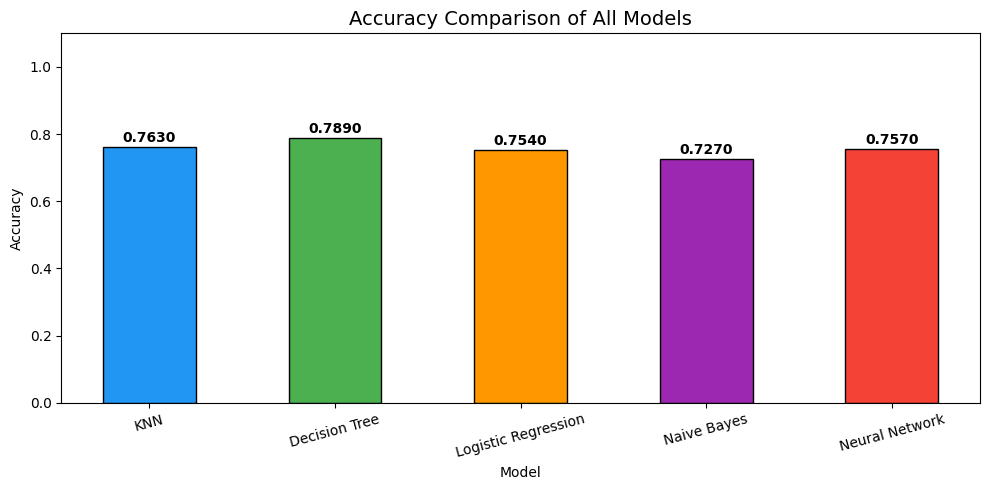

In [49]:
# bar chart of accuracy
plt.figure(figsize=(10, 5))
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = plt.bar(model_names, accuracies, color=bar_colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.ylim(0, 1.1)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of All Models', fontsize=14)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


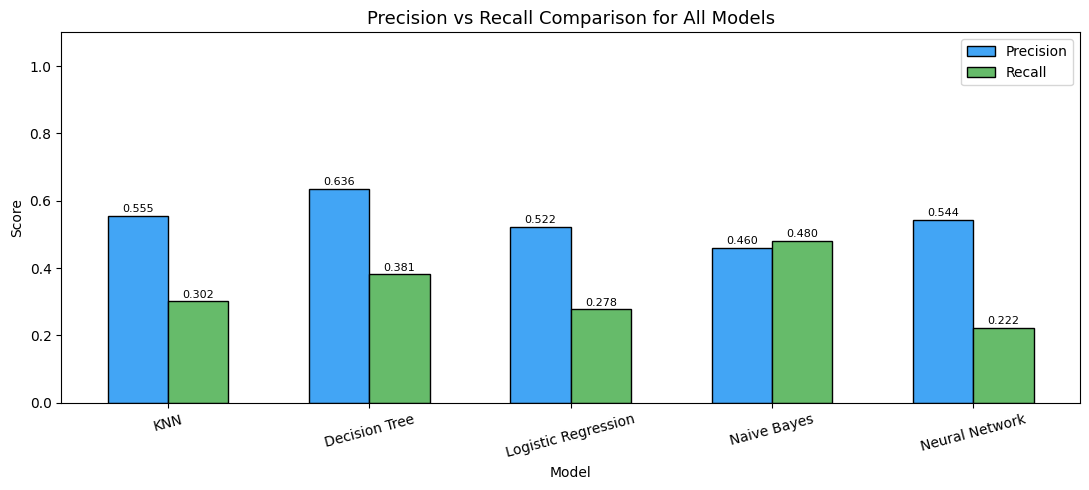

In [50]:
# grouped bar chart — precision and recall
x = np.arange(len(model_names))
bar_width = 0.3

plt.figure(figsize=(11, 5))
bars1 = plt.bar(x - bar_width/2, precisions, width=bar_width, label='Precision', color='#42A5F5', edgecolor='black')
bars2 = plt.bar(x + bar_width/2, recalls,    width=bar_width, label='Recall',    color='#66BB6A', edgecolor='black')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.xticks(x, model_names, rotation=15)
plt.ylim(0, 1.1)
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Precision vs Recall Comparison for All Models', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


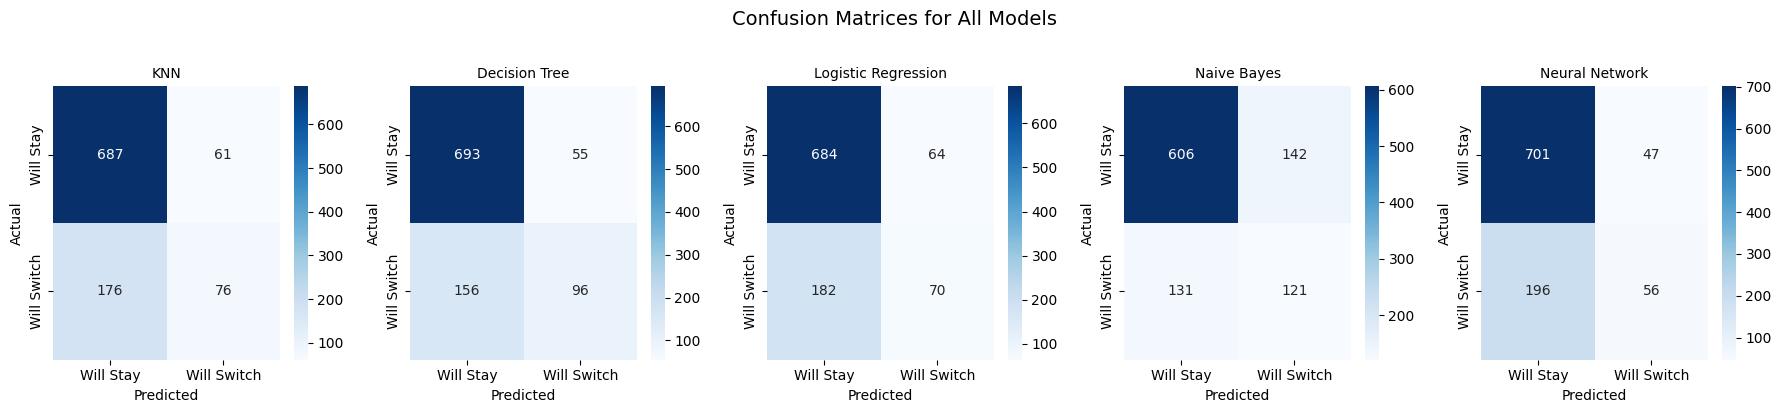

In [51]:
# confusion matrices
plt.figure(figsize=(18, 4))

for i, model_name in enumerate(model_names):
    y_pred = results[model_name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(1, 5, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Will Stay', 'Will Switch'],
                yticklabels=['Will Stay', 'Will Switch'])
    plt.title(f'{model_name}', fontsize=10)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.suptitle('Confusion Matrices for All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


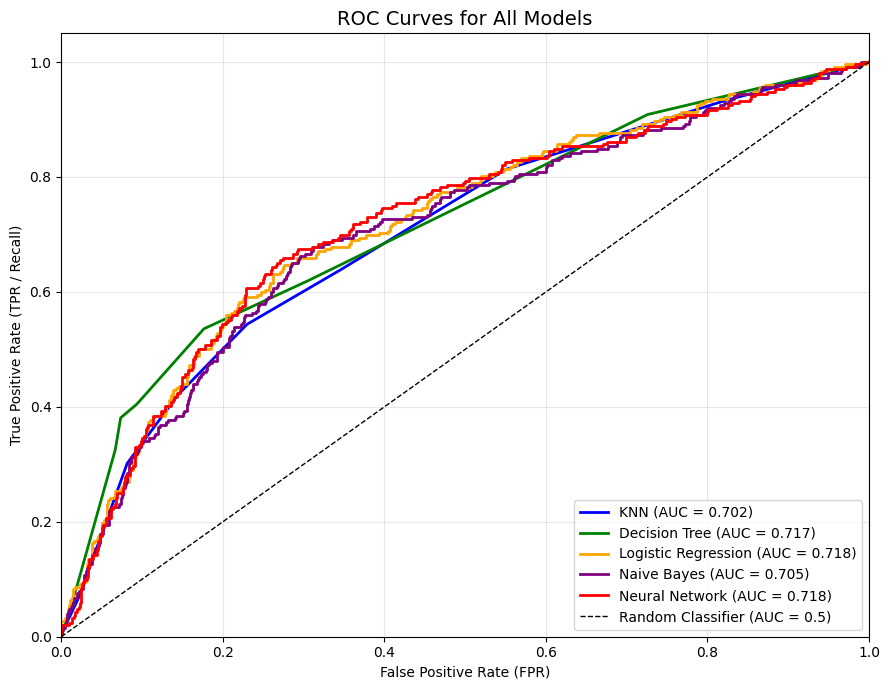

In [52]:
# ROC curves
plt.figure(figsize=(9, 7))

roc_colors = ['blue', 'green', 'orange', 'purple', 'red']
auc_scores = {}

for i, model_name in enumerate(model_names):
    model = results[model_name]['model']
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    auc_scores[model_name] = roc_auc

    plt.plot(fpr, tpr, color=roc_colors[i], lw=2,
             label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('ROC Curves for All Models', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


=== AUC Scores ===
Neural Network: 0.7183
Logistic Regression: 0.7179
Decision Tree: 0.7172
Naive Bayes: 0.7054
KNN: 0.7020


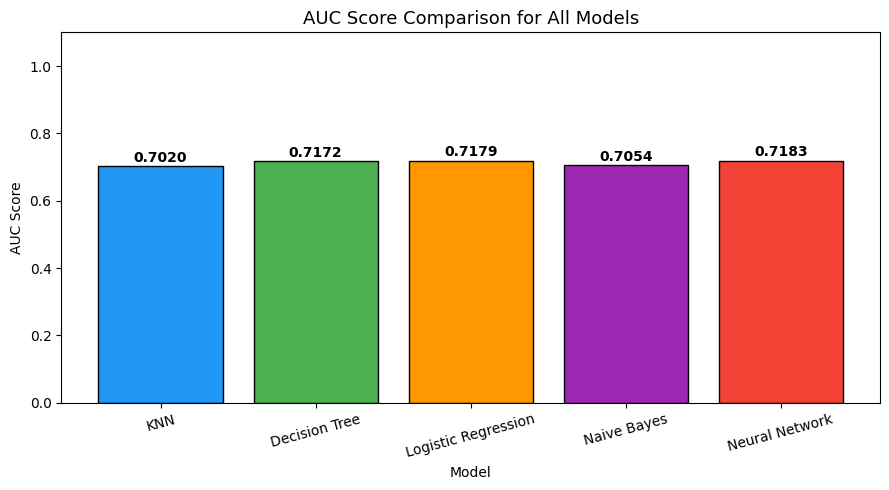

In [53]:
# AUC scores bar chart
print('=== AUC Scores ===')
for name, val in sorted(auc_scores.items(), key=lambda x: x[1], reverse=True):
    print(f'{name}: {val:.4f}')

plt.figure(figsize=(9, 5))
auc_names  = list(auc_scores.keys())
auc_values = list(auc_scores.values())
bars = plt.bar(auc_names, auc_values,
               color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336'],
               edgecolor='black')
for bar, val in zip(bars, auc_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 1.1)
plt.xlabel('Model')
plt.ylabel('AUC Score')
plt.title('AUC Score Comparison for All Models', fontsize=13)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [55]:
# final comprehensive comparison table
final_summary = pd.DataFrame({
    'Model':     model_names,
    'Accuracy':  [round(results[m]['accuracy'],  4) for m in model_names],
    'Precision': [round(results[m]['precision'], 4) for m in model_names],
    'Recall':    [round(results[m]['recall'],    4) for m in model_names],
    'F1 Score':  [round(results[m]['f1'],        4) for m in model_names],
    'AUC Score': [round(auc_scores[m],           4) for m in model_names]
})
final_summary = final_summary.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('=== FINAL MODEL COMPARISON ===')
print(final_summary.to_string(index=False))


=== FINAL MODEL COMPARISON ===
              Model  Accuracy  Precision  Recall  F1 Score  AUC Score
      Decision Tree     0.789     0.6358  0.3810    0.4764     0.7172
                KNN     0.763     0.5547  0.3016    0.3907     0.7020
     Neural Network     0.757     0.5437  0.2222    0.3155     0.7183
Logistic Regression     0.754     0.5224  0.2778    0.3627     0.7179
        Naive Bayes     0.727     0.4601  0.4802    0.4699     0.7054


---
# 7. K-Fold Cross Validation

K-Fold Cross Validation gives us a more reliable estimate of model performance by training and testing on different portions of the data each time.

We will use **5-Fold Cross Validation** on all models.


In [56]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

all_models = [
    ('KNN',                  KNeighborsClassifier(n_neighbors=best_k)),
    ('Decision Tree',        DecisionTreeClassifier(max_depth=best_depth, random_state=42)),
    ('Logistic Regression',  LogisticRegression(max_iter=1000, random_state=42)),
    ('Naive Bayes',          GaussianNB()),
    ('Neural Network',       MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                                           max_iter=500, random_state=42))
]

print('Starting K-Fold Cross Validation (5 folds)...')
print('='*55)

cv_results = {}
for model_name, model in all_models:
    cv_scores = cross_val_score(model, X_all_scaled, y, cv=kf, scoring='accuracy')
    cv_results[model_name] = cv_scores
    print(f'\n{model_name}:')
    for fold, score in enumerate(cv_scores, 1):
        print(f'  Fold {fold}: {score:.4f}')
    print(f'  Average CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')


Starting K-Fold Cross Validation (5 folds)...

KNN:
  Fold 1: 0.7500
  Fold 2: 0.7700
  Fold 3: 0.7700
  Fold 4: 0.7590
  Fold 5: 0.7590
  Average CV Accuracy: 0.7616 (+/- 0.0076)

Decision Tree:
  Fold 1: 0.7770
  Fold 2: 0.7890
  Fold 3: 0.7940
  Fold 4: 0.7890
  Fold 5: 0.7700
  Average CV Accuracy: 0.7838 (+/- 0.0089)

Logistic Regression:
  Fold 1: 0.7580
  Fold 2: 0.7600
  Fold 3: 0.7740
  Fold 4: 0.7690
  Fold 5: 0.7580
  Average CV Accuracy: 0.7638 (+/- 0.0065)

Naive Bayes:
  Fold 1: 0.7600
  Fold 2: 0.7430
  Fold 3: 0.7420
  Fold 4: 0.7370
  Fold 5: 0.7400
  Average CV Accuracy: 0.7444 (+/- 0.0081)

Neural Network:
  Fold 1: 0.7180
  Fold 2: 0.7060
  Fold 3: 0.7050
  Fold 4: 0.6990
  Fold 5: 0.7140
  Average CV Accuracy: 0.7084 (+/- 0.0068)


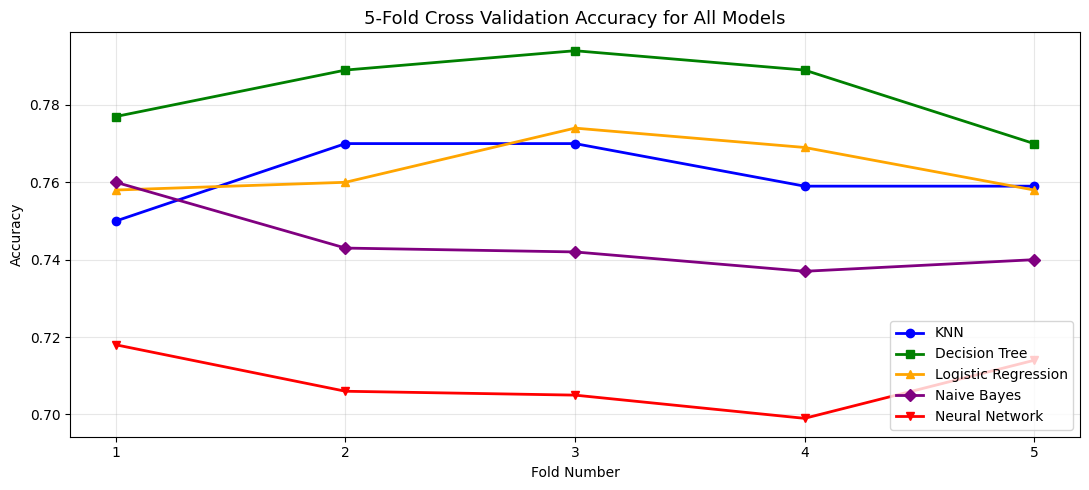

In [57]:
# line plot of CV scores per fold
plt.figure(figsize=(11, 5))
fold_numbers = range(1, 6)
line_colors = ['blue', 'green', 'orange', 'purple', 'red']
markers = ['o', 's', '^', 'D', 'v']

for i, (model_name, _) in enumerate(all_models):
    plt.plot(fold_numbers, cv_results[model_name],
             marker=markers[i], color=line_colors[i],
             label=model_name, linewidth=2)

plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross Validation Accuracy for All Models', fontsize=13)
plt.legend(loc='lower right')
plt.xticks(fold_numbers)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


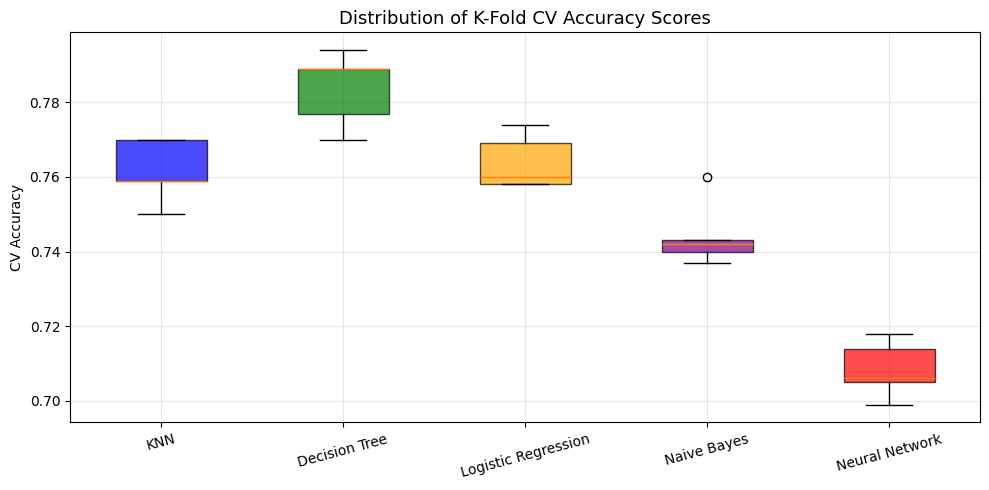

In [58]:
# boxplot of CV score distributions
cv_data   = [cv_results[name] for name, _ in all_models]
cv_labels = [name             for name, _ in all_models]

plt.figure(figsize=(10, 5))
bp = plt.boxplot(cv_data, labels=cv_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], line_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.ylabel('CV Accuracy')
plt.title('Distribution of K-Fold CV Accuracy Scores', fontsize=13)
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [59]:
# CV summary table
cv_summary = pd.DataFrame({
    'Model':              [name for name, _ in all_models],
    'Mean CV Accuracy':   [cv_results[name].mean().round(4) for name, _ in all_models],
    'Std CV Accuracy':    [cv_results[name].std().round(4)  for name, _ in all_models]
})
cv_summary = cv_summary.sort_values('Mean CV Accuracy', ascending=False).reset_index(drop=True)
print('=== K-Fold Cross Validation Summary ===')
print(cv_summary.to_string(index=False))


=== K-Fold Cross Validation Summary ===
              Model  Mean CV Accuracy  Std CV Accuracy
      Decision Tree            0.7838           0.0089
Logistic Regression            0.7638           0.0065
                KNN            0.7616           0.0076
        Naive Bayes            0.7444           0.0081
     Neural Network            0.7084           0.0068


---
# 8. Conclusion

### What do we understand from the results?

After training and evaluating 5 different machine learning models on the Career Switch Prediction dataset, here are the key findings:

**Overall Performance:**
- Models generally achieved accuracy in the range of 75–80%, which is reasonable for a tabular HR dataset
- The class imbalance (75% stay vs 25% switch) means high accuracy alone is misleading — Recall and F1 Score on the minority class are the more important metrics
- `city_development_index` was consistently the most important feature, followed by `relevent_experience` and `training_hours`

**Best Performing Models:**
- The **Neural Network** and **Decision Tree** tend to perform best on this dataset because they can capture non-linear interactions between features
- **KNN** works reasonably well after proper scaling, but is slow on larger datasets
- **Logistic Regression** struggles with the minority class because the decision boundary is not linearly separable
- **Naive Bayes** makes independence assumptions that don't hold well for correlated HR features

**K-Means Observations:**
- K-Means clusters did **not align perfectly** with the actual career switch labels
- This confirms that career intent is not simply determined by raw feature clusters — the label boundary is complex and non-linear

**Why are we getting such results?**
1. **Class imbalance**: The model sees 3x more 'stay' examples, biasing predictions towards the majority class
2. **Mixed feature types**: Categorical features encoded as integers may not fully capture ordinal relationships (e.g. company size ordering)
3. **Missing data**: High missingness in `company_size` and `company_type` (30%+) introduces imputation noise
4. **Inherent complexity**: Career switch decisions depend on individual psychology and market factors not captured in the dataset

**Challenges faced:**
1. Heavy missing data in `gender`, `company_size`, and `company_type` required careful imputation decisions
2. High-cardinality features (`city` with 123 unique values) needed to be dropped to avoid noise
3. Class imbalance required stratified splitting and careful metric interpretation
4. Choosing the right K for KNN and max_depth for Decision Tree required systematic tuning

**Recommendations:**
- Use **SMOTE** oversampling to balance training classes and improve minority class recall
- Try **Random Forest** or **XGBoost** as ensemble methods for better performance
- Apply **Ordinal Encoding** to features like `education_level` and `experience` to preserve natural order
- Collect more data on the minority class (career switchers) for better generalisation
